In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

In [2]:
# read the last folder in the results folder
    
path = "results/20260331_142801_nsga_ckpts"
# get the last folder in the results folder
last_folder = sorted(glob.glob(os.path.join(path, "*/")))[-1]
print(f"Reading logs from {last_folder}")
# read the logs
f = np.load(os.path.join(last_folder, "f.npy"))
f_best = np.load(os.path.join(last_folder, "f_best.npy"))
logs = {"f": f, "f_best": f_best}


Reading logs from results/20260331_142801_nsga_ckpts/95/


In [3]:
path = "results/20260401_113146_nsga_ckpts"
# get the last folder in the results folder, which is the one with the most recent logs
last_folder = sorted(glob.glob(os.path.join(path, "*/")))[-1]
# Fix lexicographic sorting (e.g., "95" > "590" as strings) by sorting numerically
folders = glob.glob(os.path.join(path, "*/"))
last_folder = max(
    folders,
    key=lambda d: int(os.path.basename(os.path.normpath(d)))
)
print(f"Reading logs from {last_folder}")

f = np.load(os.path.join(last_folder, "f.npy"))
f_best = np.load(os.path.join(last_folder, "f_best.npy"))
logs = {"f": f, "f_best": f_best}
print(logs["f_best"])

Reading logs from results/20260401_113146_nsga_ckpts/999/
[-23.58088903 -78.59957411]


In [4]:
f_best = np.load("results/20260401_113146_nsga_ckpts/10/f_best.npy")
logs = {"f": f, "f_best": f_best}
print(logs["f_best"])

[-26.6291024 -86.3030481]


In [5]:
f_best = np.load("results/20260401_113146_nsga_ckpts/550/f_best.npy")
logs = {"f": f, "f_best": f_best}
print(np.max(logs["f"], axis=0))

[-20.92927916 -69.24917967]


Max folder: 465


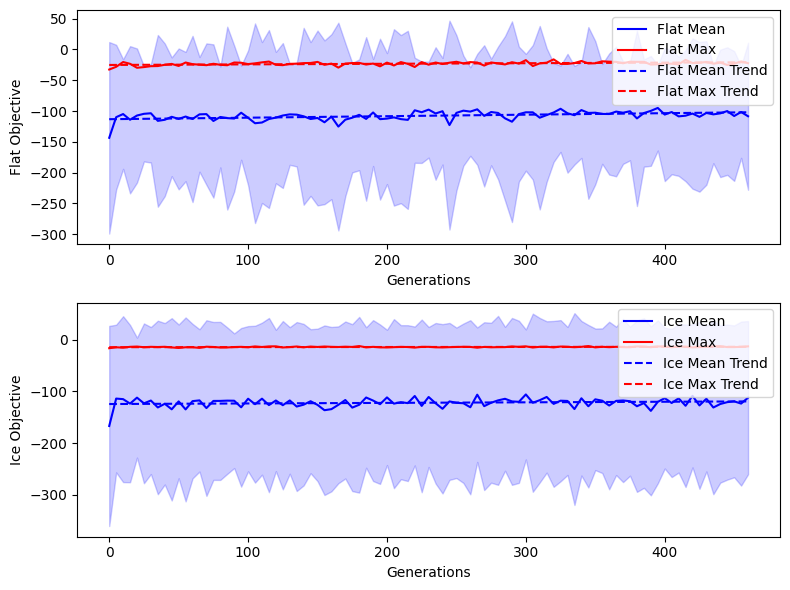

In [6]:
# plot mean and max of both objectives in f over generations. 
# For that read folders with f_best = np.load("results/20260401_113146_nsga_ckpts/i/f.npy") 
# for i in range(0, 600, 10) and plot the mean and max of f on y and generations on x on two subplots.
flat_mean = []
flat_max = []
flat_std = []
ice_mean = []
ice_max = []
ice_std = []


path = "results/20260402_091913_nsga_ckpts"

max_folder = max([int(d) for d in os.listdir(path) if d.isdigit()])
print(f"Max folder: {max_folder}")

fig,axs = plt.subplots(2,1, figsize=(8, 6))
for i in range(0, max_folder, 5):
    f = np.load(f"{path}/{i}/f.npy")
    flat_mean.append(np.mean(f, axis=0)[0])
    flat_max.append(np.max(f, axis=0)[0])
    ice_mean.append(np.mean(f, axis=0)[1])
    ice_max.append(np.max(f, axis=0)[1])
    flat_std.append(np.std(f, axis=0)[0])
    ice_std.append(np.std(f, axis=0)[1])

generations = np.arange(0, max_folder, 5)

axs[0].plot(generations, flat_mean, label="Flat Mean", color="blue")
axs[0].plot(generations, flat_max, label="Flat Max", color="red")
# add trend lines for both objectives
z = np.polyfit(generations, flat_mean, 1)
p = np.poly1d(z)
axs[0].plot(generations, p(generations), label="Flat Mean Trend", linestyle="--", color="blue")
z = np.polyfit(generations, flat_max, 1)
p = np.poly1d(z)
axs[0].plot(generations, p(generations), label="Flat Max Trend", linestyle="--", color="red")    
axs[0].set_xlabel("Generations")
axs[0].set_ylabel("Flat Objective")
axs[0].legend(loc="upper right")
# axs[0].set_ylim([-150,0])


axs[1].plot(generations, ice_mean, label="Ice Mean", color="blue")
axs[1].plot(generations, ice_max, label="Ice Max", color="red")
# add trend lines for both objectives
z = np.polyfit(generations, ice_mean, 1)
p = np.poly1d(z)
axs[1].plot(generations, p(generations), label="Ice Mean Trend", linestyle="--", color="blue")
z = np.polyfit(generations, ice_max, 1)
p = np.poly1d(z)
axs[1].plot(generations, p(generations), label="Ice Max Trend", linestyle="--", color="red")
axs[1].set_xlabel("Generations")
axs[1].set_ylabel("Ice Objective")
axs[1].legend(loc="upper right")
# axs[1].set_ylim([-150,0])

# plot the std of both objectives in f over generations around the mean as a shaded area
axs[0].fill_between(generations, np.array(flat_mean) - np.array(flat_std), np.array(flat_mean) + np.array(flat_std), alpha=0.2, color="blue")
axs[1].fill_between(generations, np.array(ice_mean) - np.array(ice_std), np.array(ice_mean) + np.array(ice_std), alpha=0.2, color="blue")


fig.tight_layout()
